In [1]:
# BLOQUE 1: DESCARGAR ZIP
!gsutil cp "gs://endomondo-dataset/fitrec-dataset.zip" ./fitrec-dataset.zip
!ls -la *.zip

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://endomondo-dataset/fitrec-dataset.zip...
- [1 files][  1.9 GiB/  1.9 GiB]   37.7 MiB/s                                   
Operation completed over 1 objects/1.9 GiB.                                      
-rw-r--r-- 1 jupyter jupyter 2019540074 Apr 12 12:38 fitrec-dataset.zip


In [2]:
import zipfile

with zipfile.ZipFile("./fitrec-dataset.zip", "r") as zip_obj:
    contenido = zip_obj.namelist()
    print("Archivos dentro del ZIP:")
    for f in contenido:
        print(f"  {f}")
    zip_obj.extractall("./data/")

print("\nExtraído correctamente")
import os
for root, dirs, files in os.walk("./data/"):
    for file in files:
        ruta = os.path.join(root, file)
        size = os.path.getsize(ruta) / 1e6
        print(f"  {ruta} ({size:.1f} MB)")

Archivos dentro del ZIP:
  endomondoHR.json

Extraído correctamente
  ./data/endomondoHR.json (6568.4 MB)


In [3]:
import ast
import pandas as pd
import numpy as np
import os

JSON_PATH = "./data/endomondoHR.json"

print("Cargando 20.000 filas con ast.literal_eval...")

rows = []
errores = 0

with open(JSON_PATH, "r") as f:
    for i, line in enumerate(f):
        if i >= 20000:
            break
        line = line.strip()
        if not line:
            continue
        try:
            row = ast.literal_eval(line)
            rows.append(row)
        except Exception as e:
            errores += 1
            if errores <= 3:
                print(f"Error línea {i}: {e}")

df = pd.DataFrame(rows)
print(f"\n✅ Filas parseadas: {len(rows)}")
print(f"⚠️ Errores: {errores}")
print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
df.head(3)

Cargando 20.000 filas con ast.literal_eval...

✅ Filas parseadas: 20000
⚠️ Errores: 0
Shape: (20000, 11)
Columnas: ['speed', 'altitude', 'gender', 'heart_rate', 'id', 'url', 'userId', 'timestamp', 'longitude', 'latitude', 'sport']


,speed,altitude,gender,heart_rate,id,url,userId,timestamp,longitude,latitude,sport
0,"[6.8652, 16.4736, 19.1988, 20.4804, 31.3956, 3...","[41.6, 40.6, 40.6, 38.4, 37.0, 34.0, 34.0, 34....",male,"[100, 111, 120, 119, 120, 116, 125, 128, 131, ...",396826535,https://www.endomondo.com/users/10921915/worko...,10921915,"[1408898746, 1408898754, 1408898765, 140889877...","[24.64977040886879, 24.65014273300767, 24.6509...","[60.173348765820265, 60.173239801079035, 60.17...",bike
1,"[9.0792, 13.284, 15.9336, 10.9476, 16.1676, 30...","[38.4, 39.0, 39.0, 38.2, 36.8, 36.8, 36.8, 35....",male,"[100, 105, 111, 110, 108, 115, 126, 130, 132, ...",392337038,https://www.endomondo.com/users/10921915/worko...,10921915,"[1408221682, 1408221687, 1408221699, 140822170...","[24.649855233728886, 24.65015547350049, 24.650...","[60.173247596248984, 60.17320962622762, 60.172...",bike
2,"[4.0464, 13.8204, 16.9776, 19.9404, 28.7856, 3...","[76.4, 73.2, 72.4, 73.0, 73.0, 70.8, 69.2, 69....",male,"[99, 105, 113, 110, 109, 110, 108, 121, 116, 1...",389643739,https://www.endomondo.com/users/10921915/worko...,10921915,"[1407858459, 1407858466, 1407858478, 140785849...","[24.64995657093823, 24.650197718292475, 24.651...","[60.17326201312244, 60.173205351457, 60.172969...",bike


In [4]:
# INSPECCIÓN CORREGIDA (sin duplicated sobre listas)

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())

print("\nTipos:")
print(df.dtypes)

print("\nNulos (%):")
print((df.isnull().mean() * 100).sort_values(ascending=False).head(15))

# Duplicados solo en columnas escalares
cols_escalares = [col for col in df.columns 
                  if not df[col].apply(lambda x: isinstance(x, list)).any()]
print(f"\nColumnas escalares: {cols_escalares}")
print(f"Duplicados (cols escalares): {df[cols_escalares].duplicated().sum()}")

# Ver valores únicos de sport
if 'sport' in df.columns:
    print("\nValores sport:")
    print(df['sport'].value_counts().head(10))

# Ver ejemplo fila completa
print("\nEjemplo fila 0:")
for col in df.columns:
    val = df[col].iloc[0]
    if isinstance(val, list):
        print(f"  {col}: lista de {len(val)} elementos → primeros 3: {val[:3]}")
    else:
        print(f"  {col}: {val}")

Shape: (20000, 11)

Columnas: ['speed', 'altitude', 'gender', 'heart_rate', 'id', 'url', 'userId', 'timestamp', 'longitude', 'latitude', 'sport']

Tipos:
speed         object
altitude      object
gender        object
heart_rate    object
id             int64
url           object
userId         int64
timestamp     object
longitude     object
latitude      object
sport         object
dtype: object

Nulos (%):
speed         80.005
altitude       0.000
gender         0.000
heart_rate     0.000
id             0.000
url            0.000
userId         0.000
timestamp      0.000
longitude      0.000
latitude       0.000
sport          0.000
dtype: float64

Columnas escalares: ['gender', 'id', 'url', 'userId', 'sport']
Duplicados (cols escalares): 0

Valores sport:
sport
run                        9921
bike                       6741
bike (transport)           1394
mountain bike               807
orienteering                440
walk                        385
core stability training      87
ka

In [5]:
import numpy as np
import pandas as pd

# FILTRAR SOLO RUNNING CON SPEED
df_run = df[
    (df['sport'] == 'run') & 
    (df['speed'].notnull())
].copy()

print(f"Running con speed: {df_run.shape[0]} entrenamientos")

# FUNCIONES AGREGACIÓN
def agg_list(lst):
    if isinstance(lst, list) and len(lst) > 0:
        arr = np.array(lst, dtype=float)
        return {
            'mean': np.nanmean(arr),
            'max':  np.nanmax(arr),
            'min':  np.nanmin(arr),
            'std':  np.nanstd(arr),
            'n':    len(arr)
        }
    return {'mean': np.nan, 'max': np.nan, 'min': np.nan, 'std': np.nan, 'n': 0}

# FEATURES SECUENCIALES
for col in ['speed', 'altitude', 'heart_rate']:
    agg = df_run[col].apply(agg_list).apply(pd.Series)
    for stat in ['mean', 'max', 'min', 'std', 'n']:
        df_run[f"{col}_{stat}"] = agg[stat]

# FEATURES TEMPORALES
def duration_seconds(ts):
    if isinstance(ts, list) and len(ts) > 1:
        return ts[-1] - ts[0]
    return np.nan

df_run['duration_s']   = df_run['timestamp'].apply(duration_seconds)
df_run['duration_min'] = df_run['duration_s'] / 60

# FEATURES DISTANCIA (desde GPS)
def haversine_total(lats, lons):
    if not isinstance(lats, list) or len(lats) < 2:
        return np.nan
    R = 6371000  # metros
    total = 0.0
    for i in range(1, len(lats)):
        lat1, lat2 = np.radians(lats[i-1]), np.radians(lats[i])
        lon1, lon2 = np.radians(lons[i-1]), np.radians(lons[i])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        total += R * 2 * np.arcsin(np.sqrt(a))
    return total

print("Calculando distancia GPS (puede tardar ~30s)...")
df_run['distance_m']  = df_run.apply(
    lambda r: haversine_total(r['latitude'], r['longitude']), axis=1
)
df_run['distance_km'] = df_run['distance_m'] / 1000

# FEATURES DERIVADAS
df_run['pace_min_km']     = df_run['duration_min'] / df_run['distance_km']
df_run['altitude_gain']   = df_run['altitude'].apply(
    lambda x: np.sum(np.diff(x)[np.diff(x) > 0]) if isinstance(x, list) else np.nan
)
df_run['hr_variability']  = df_run['heart_rate_std'] / df_run['heart_rate_mean']
df_run['speed_variability'] = df_run['speed_std'] / df_run['speed_mean']
df_run['gender_bin']      = (df_run['gender'] == 'male').astype(int)

# VARIABLE OBJETIVO: heart_rate_mean (proxy de esfuerzo/fatiga)
df_run['target_hr'] = df_run['heart_rate_mean']

# COLUMNAS FINALES
feature_cols = [
    'speed_mean', 'speed_max', 'speed_std',
    'altitude_mean', 'altitude_gain',
    'heart_rate_min', 'heart_rate_max', 'heart_rate_std',
    'duration_min', 'distance_km', 'pace_min_km',
    'hr_variability', 'speed_variability', 'gender_bin',
    'target_hr'
]

df_final = df_run[feature_cols].dropna()

print(f"\n✅ Shape final: {df_final.shape}")
print(f"✅ Features: {len(feature_cols)-1}")
print(f"✅ Target: target_hr (HR media como proxy de esfuerzo)")
print(f"\nEstadísticas target:")
print(df_final['target_hr'].describe())

# GUARDAR
df_final.to_csv("./df_features_day2.csv", index=False)
print("\n✅ Guardado: df_features_day2.csv")

Running con speed: 2070 entrenamientos
Calculando distancia GPS (puede tardar ~30s)...

✅ Shape final: (2069, 15)
✅ Features: 14
✅ Target: target_hr (HR media como proxy de esfuerzo)

Estadísticas target:
count    2069.000000
mean      144.990366
std        13.212511
min        78.571429
25%       136.972000
50%       144.718919
75%       153.738000
max       219.082164
Name: target_hr, dtype: float64

✅ Guardado: df_features_day2.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# CARGAR
df = pd.read_csv("./df_features_day2.csv")
print("Shape:", df.shape)

X = df.drop(columns=['target_hr'])
y = df['target_hr']

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Shape: (2069, 15)
Train: (1655, 14) | Test: (414, 14)


In [7]:
# DEFINIR MODELOS
models = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    "Ridge": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, random_state=42
    )
}

# ENTRENAR Y EVALUAR
results = []
for name, model in models.items():
    print(f"Entrenando {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    # Cross-val
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    
    results.append({
        'Modelo': name,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'R2_test': round(r2, 3),
        'R2_cv5': round(cv_r2, 3)
    })
    print(f"  MAE={mae:.2f} | RMSE={rmse:.2f} | R2={r2:.3f} | CV_R2={cv_r2:.3f}")

df_results = pd.DataFrame(results).sort_values('R2_test', ascending=False)
print("\n=== TABLA COMPARATIVA ===")
print(df_results.to_string(index=False))

Entrenando Linear Regression...
  MAE=3.68 | RMSE=5.22 | R2=0.825 | CV_R2=0.799
Entrenando Ridge...
  MAE=3.72 | RMSE=5.27 | R2=0.822 | CV_R2=0.800
Entrenando Random Forest...
  MAE=3.56 | RMSE=4.93 | R2=0.844 | CV_R2=0.755
Entrenando Gradient Boosting...
  MAE=3.58 | RMSE=5.01 | R2=0.839 | CV_R2=0.785

=== TABLA COMPARATIVA ===
           Modelo   MAE  RMSE  R2_test  R2_cv5
    Random Forest 3.558 4.933    0.844   0.755
Gradient Boosting 3.577 5.013    0.839   0.785
Linear Regression 3.684 5.222    0.825   0.799
            Ridge 3.723 5.269    0.822   0.800


In [9]:
!pip install xgboost lightgbm shap -q

In [10]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# XGBoost con tuning
xgb = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

print("Entrenando XGBoost con GridSearch (puede tardar ~2 min)...")
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

y_pred_xgb = grid.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"\nMejores parámetros: {grid.best_params_}")
print(f"R² CV5:  {grid.best_score_:.3f}")
print(f"MAE:     {mae_xgb:.3f} bpm")
print(f"R² test: {r2_xgb:.3f}")

# LightGBM rápido
print("\nEntrenando LightGBM...")
lgbm = LGBMRegressor(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
print(f"LightGBM → MAE: {mean_absolute_error(y_test, y_pred_lgbm):.3f} | R²: {r2_score(y_test, y_pred_lgbm):.3f}")

Entrenando XGBoost con GridSearch (puede tardar ~2 min)...

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
R² CV5:  0.883
MAE:     2.962 bpm
R² test: 0.890

Entrenando LightGBM...
LightGBM → MAE: 3.042 | R²: 0.868


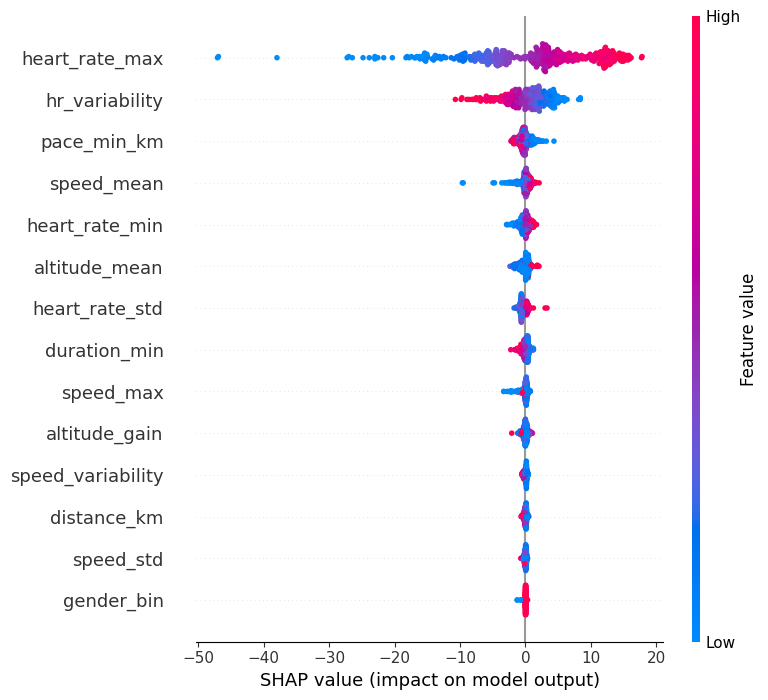

✅ shap_rf.png


In [13]:
# ALTERNATIVA: SHAP con Random Forest (100% compatible)
from sklearn.ensemble import RandomForestRegressor

rf_final = models["Random Forest"]  # Ya entrenado

explainer_rf = shap.TreeExplainer(rf_final)
shap_values_rf = explainer_rf.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf, X_test,
                  feature_names=X_test.columns.tolist(),
                  show=False)
plt.tight_layout()
plt.savefig("./shap_rf.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ shap_rf.png")

In [16]:
import joblib
import json
import numpy as np

# GUARDAR MODELO XGBOOST
joblib.dump(grid.best_estimator_, "./modelo_xgboost.pkl")
print("✅ Modelo guardado: modelo_xgboost.pkl")

# GUARDAR FEATURE NAMES Y STATS PARA LA APP
feature_names = X_train.columns.tolist()
feature_stats = {
    col: {
        'mean': float(X_train[col].mean()),
        'std':  float(X_train[col].std()),
        'min':  float(X_train[col].min()),
        'max':  float(X_train[col].max())
    }
    for col in feature_names
}

with open("./feature_stats.json", "w") as f:
    json.dump({'features': feature_names, 'stats': feature_stats}, f)

print("✅ Stats guardadas: feature_stats.json")
print("Features del modelo:", feature_names)

✅ Modelo guardado: modelo_xgboost.pkl
✅ Stats guardadas: feature_stats.json
Features del modelo: ['speed_mean', 'speed_max', 'speed_std', 'altitude_mean', 'altitude_gain', 'heart_rate_min', 'heart_rate_max', 'heart_rate_std', 'duration_min', 'distance_km', 'pace_min_km', 'hr_variability', 'speed_variability', 'gender_bin']
